In [1]:
import pandas as pd
df=pd.read_csv('c:/data/ozone/ozone2.csv')
df.head()

,Month,Day,Solar.R,Wind,Temp,Ozone,Result
0,5,1,190.000000,7.4,67,41,0
1,5,2,118.000000,8.0,72,36,0
2,5,3,149.000000,12.6,74,12,0
3,5,4,313.000000,11.5,62,18,0
4,5,5,185.931507,14.3,56,42,1


In [2]:
X=df[['Solar.R','Wind','Temp']]
y=df['Ozone']

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=7)

In [4]:
from tensorflow.keras.models import Sequential  #신경망모형
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(len(X_train.columns),)), #입력층
    #은닉층 노드 개수(8,4,2)의 세 개 층
    Dense(8, activation='relu'),  #hidden1
    Dense(4, activation='relu'),  #hidden2
    Dense(2, activation='relu'),  #hidden3
    Dense(1)                     #출력층
])

model.compile(
    loss='mse', #손실함수:오차계산(평균제곱오차)
    optimizer='adam', #최적화함수:오차 최적으로 수정
    metrics=['mse','mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

<Axes: >

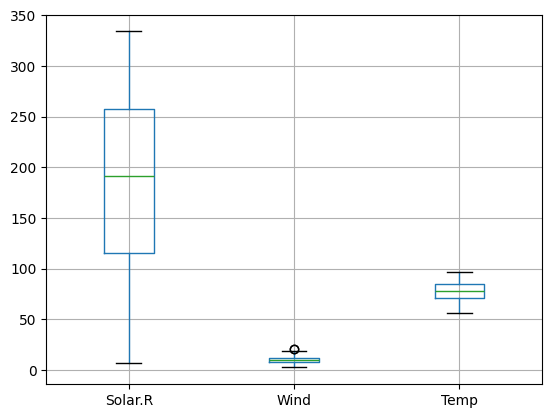

In [5]:
X_train.boxplot()

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

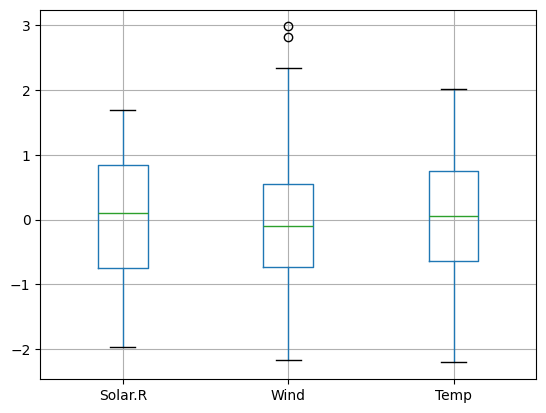

In [7]:
import matplotlib.pyplot as plt
X_train_scaled.boxplot()
plt.show()

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
hist=model.fit(X_train_scaled,y_train,epochs=500,validation_split=0.2,callbacks=[early_stopping])
#validation_loss : 검증 데이터로 계산한 오차/학습에는 사용되지 않음/모델의 실전 성능(일반화 성능) 지표

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 2731.3428 - mae: 42.0938 - mse: 2731.3428 - val_loss: 2013.7672 - val_mae: 38.2764 - val_mse: 2013.7672
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2729.8047 - mae: 42.0770 - mse: 2729.8047 - val_loss: 2012.4972 - val_mae: 38.2620 - val_mse: 2012.4972
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2728.3850 - mae: 42.0617 - mse: 2728.3850 - val_loss: 2011.3029 - val_mae: 38.2484 - val_mse: 2011.3029
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2726.9861 - mae: 42.0470 - mse: 2726.9861 - val_loss: 2010.1703 - val_mae: 38.2355 - val_mse: 2010.1703
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2725.7610 - mae: 42.0333 - mse: 2725.7610 - val_loss: 2009.0620 - val_mae: 38.2229 - val_mse: 2009.0620
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2724.4644 - mae: 42.0201 - mse: 2724.4644 - val_loss: 2007.9822 - val_mae: 38.2106 - val_mse: 2007.9822
Epoch 7/500
4/4 ━━━━━━━━━━━━

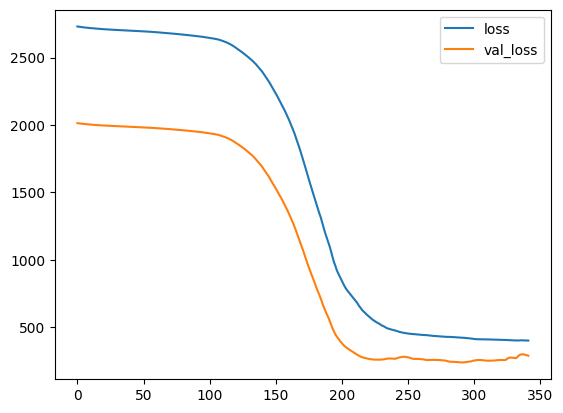

In [9]:
#loss = 훈련 데이터 MSE
#val_loss = 검증 데이터 MSE
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

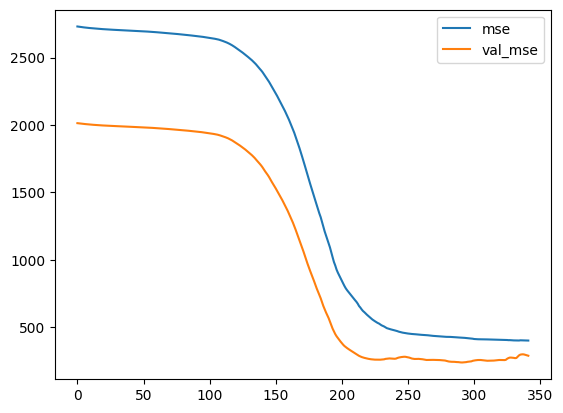

In [10]:
plt.plot(hist.history['mse'])
plt.plot(hist.history['val_mse'])
plt.legend(['mse','val_mse'])
plt.show()

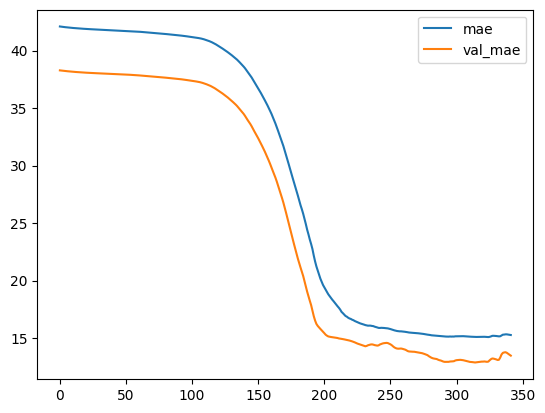

In [11]:
plt.show()
plt.plot(hist.history['mae'])
plt.plot(hist.history['val_mae'])
plt.legend(['mae', 'val_mae'])
plt.show()

In [14]:
scores = model.evaluate(X_train_scaled,y_train)
print(scores)

scores = model.evaluate(X_test_scaled,y_test)
print(scores)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 383.4032 - mae: 14.6817 - mse: 383.4032 
[383.4031677246094, 383.4031677246094, 14.681730270385742]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 305.1132 - mae: 13.3370 - mse: 305.1132
[305.1131591796875, 305.1131591796875, 13.336970329284668]


In [13]:
from sklearn.metrics import r2_score
pred = model.predict(X_test_scaled)
r2_score(y_test,pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


0.4731431007385254